# Multivariate Multi-Horizon Time Series Forecasting
## Prediksi Harga Penutupan (Close) Bitcoin - Data Hourly

**Nama**: Rifqi Zaghlul  
**Submission**: Submission Akhir Deep Learning with TensorFlow Mahir (DLTM)  
**Dataset**: Multivariate Crypto Data Hourly since 2017 to 2023  
**Target**: Prediksi harga Close Bitcoin 24 langkah ke depan (Multi-Step Forecasting)

# Persipan Data

## Import Library

In [25]:
# Import Library
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import kagglehub

In [26]:
# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.20.0
GPU available: True


## Load Dataset

In [27]:
# Load Dataset dari Google Drive

csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'

df_raw = pd.read_csv(csv_url)

# Parse kolom Date
df_raw['Date'] = pd.to_datetime(df_raw['Date'], format='mixed')
df_raw = df_raw.set_index('Date').sort_index()

print(f'Shape dataset  : {df_raw.shape}')
print(f'Kolom          : {df_raw.columns.tolist()}')
print(f'Periode data   : {df_raw.index.min()} s.d. {df_raw.index.max()}')
print(f'Missing values :')
print(df_raw.isnull().sum())
df_raw.head()

Shape dataset  : (53150, 6)
Kolom          : ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']
Periode data   : 2017-09-21 09:00:00 s.d. 2023-10-19 23:00:00
Missing values :
Close          0
Volume USDT    0
RSI            0
MACD_Hist      0
ATR            0
KAMAO          0
dtype: int64


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
Date,,,,,,
2017-09-21 09:00:00,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
2017-09-21 10:00:00,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2017-09-21 11:00:00,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
2017-09-21 12:00:00,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
2017-09-21 13:00:00,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [28]:
# Statistik Deskriptif
print('=== Statistik Deskriptif ===')
df_raw.describe()

=== Statistik Deskriptif ===


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
count,53150.000000,5.315000e+04,53150.000000,53150.000000,53150.000000,53150.000000
mean,20595.357333,6.919215e+07,50.403605,0.528272,221.733334,0.229762
std,15822.296994,1.059041e+08,3.210682,353.293188,208.401440,5.168655
min,3172.050000,0.000000e+00,35.178834,-1885.690630,17.436266,-31.767152
25%,7976.915000,1.012558e+07,48.294197,-115.601600,72.702488,-2.717470
50%,13878.095000,2.766119e+07,50.038483,10.154419,128.787616,-0.032747
75%,29646.720000,8.944278e+07,52.406274,122.367509,325.616826,3.162442
max,68633.690000,3.005634e+09,64.657108,1430.405758,1004.531407,39.740297


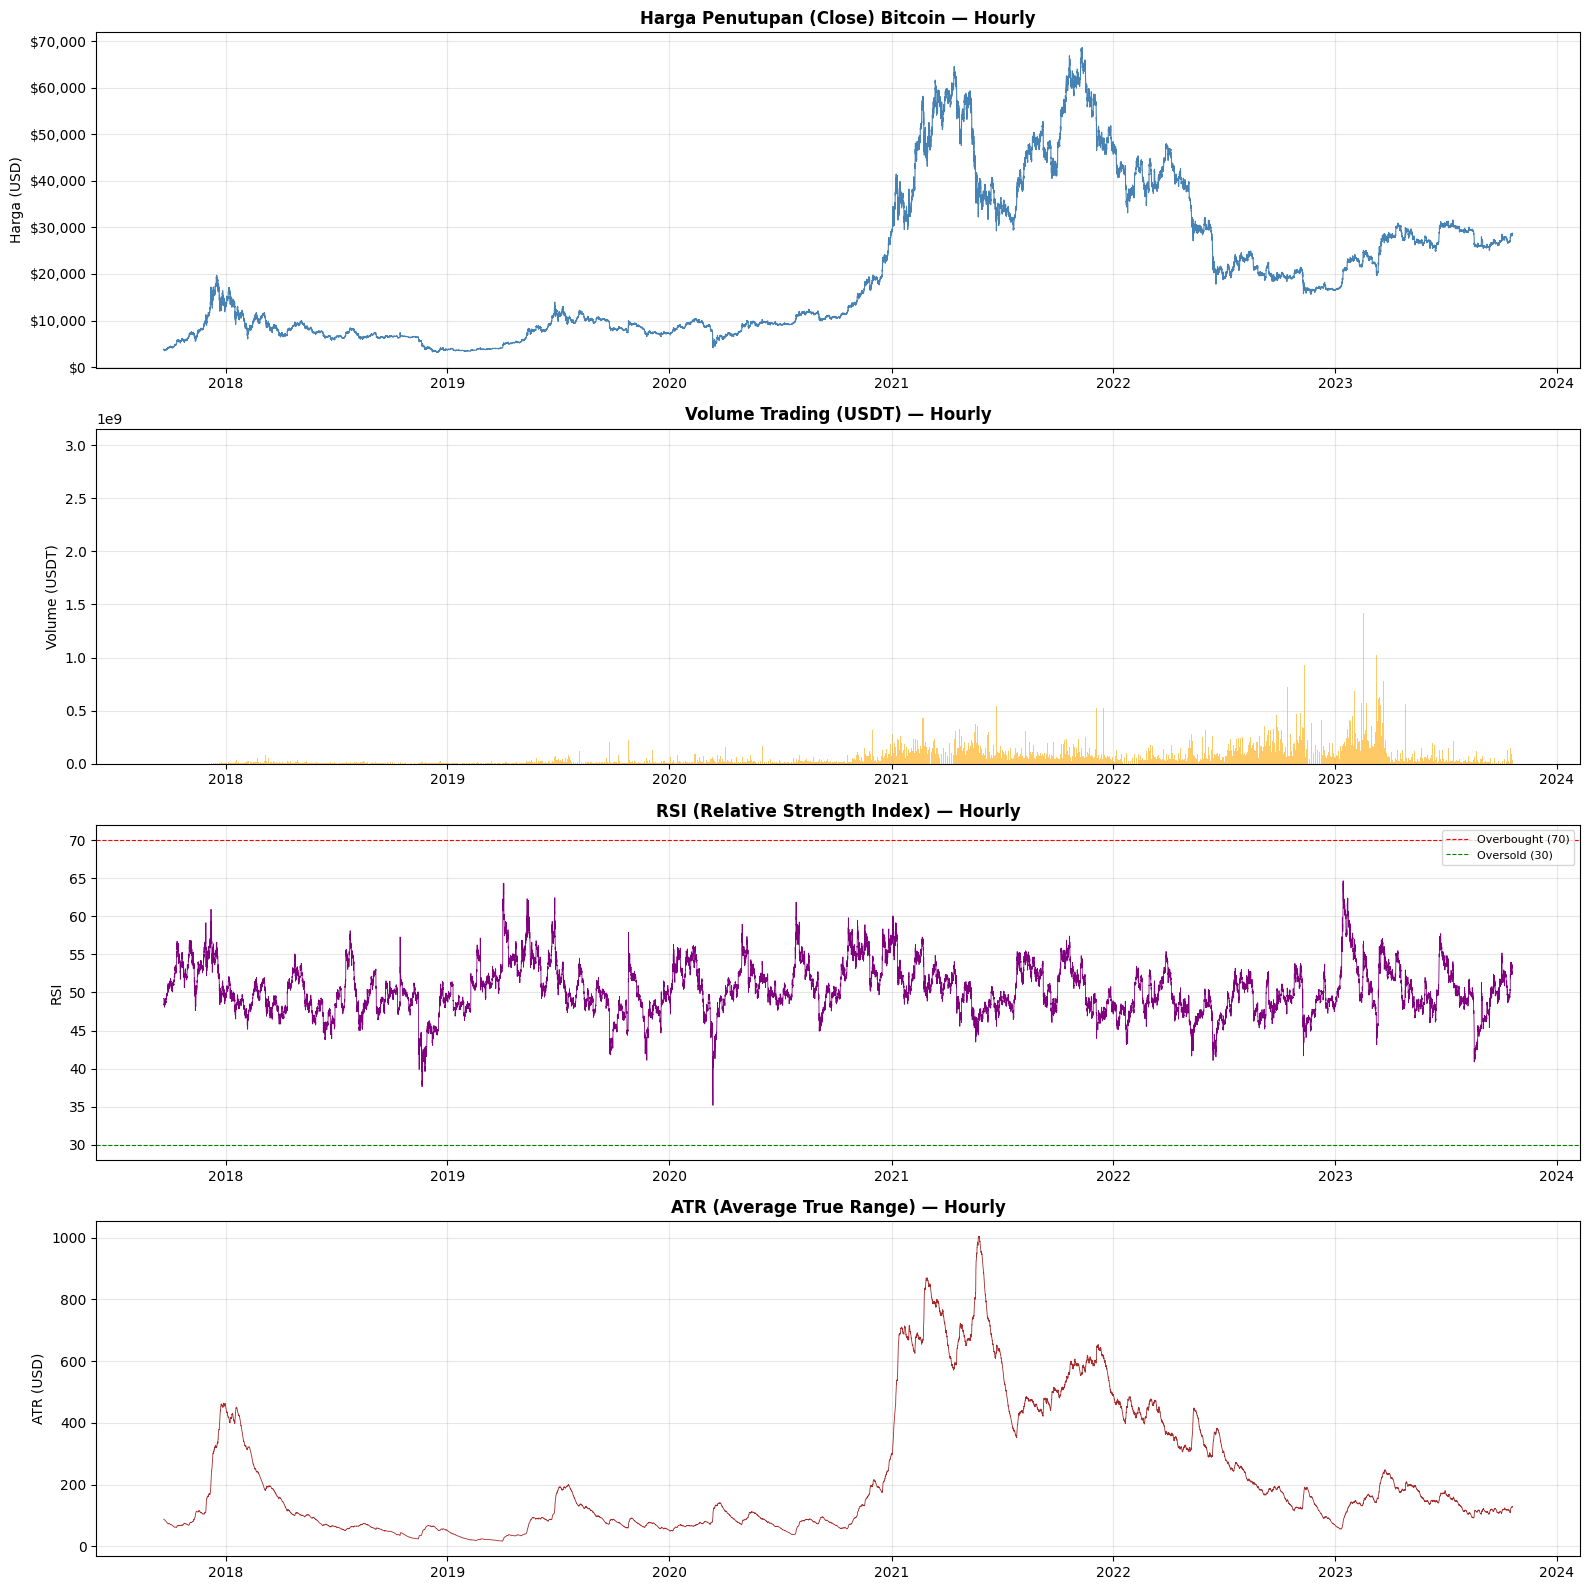

In [29]:
# Visualisasi Time Series Semua Fitur
fig, axes = plt.subplots(4, 1, figsize=(16, 16))

# Close Price
axes[0].plot(df_raw.index, df_raw['Close'], color='steelblue', linewidth=0.8)
axes[0].set_title('Harga Penutupan (Close) Bitcoin — Hourly', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Harga (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(alpha=0.3)

# Volume USDT
axes[1].bar(df_raw.index, df_raw['Volume USDT'], color='orange', alpha=0.6, width=0.04)
axes[1].set_title('Volume Trading (USDT) — Hourly', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Volume (USDT)')
axes[1].grid(alpha=0.3)

# RSI
axes[2].plot(df_raw.index, df_raw['RSI'], color='purple', linewidth=0.6)
axes[2].axhline(70, color='red',   linestyle='--', linewidth=0.8, label='Overbought (70)')
axes[2].axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
axes[2].set_title('RSI (Relative Strength Index) — Hourly', fontsize=12, fontweight='bold')
axes[2].set_ylabel('RSI')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

# ATR
axes[3].plot(df_raw.index, df_raw['ATR'], color='brown', linewidth=0.6)
axes[3].set_title('ATR (Average True Range) — Hourly', fontsize=12, fontweight='bold')
axes[3].set_ylabel('ATR (USD)')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

In [30]:
# Info & Statistik Deskriptif
print('=== Info Dataset ===')
df_raw.info()
print('\n=== Statistik Deskriptif ===')
df_raw.describe()

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 53150 entries, 2017-09-21 09:00:00 to 2023-10-19 23:00:00
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Close        53150 non-null  float64
 1   Volume USDT  53150 non-null  float64
 2   RSI          53150 non-null  float64
 3   MACD_Hist    53150 non-null  float64
 4   ATR          53150 non-null  float64
 5   KAMAO        53150 non-null  float64
dtypes: float64(6)
memory usage: 2.8 MB

=== Statistik Deskriptif ===


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
count,53150.000000,5.315000e+04,53150.000000,53150.000000,53150.000000,53150.000000
mean,20595.357333,6.919215e+07,50.403605,0.528272,221.733334,0.229762
std,15822.296994,1.059041e+08,3.210682,353.293188,208.401440,5.168655
min,3172.050000,0.000000e+00,35.178834,-1885.690630,17.436266,-31.767152
25%,7976.915000,1.012558e+07,48.294197,-115.601600,72.702488,-2.717470
50%,13878.095000,2.766119e+07,50.038483,10.154419,128.787616,-0.032747
75%,29646.720000,8.944278e+07,52.406274,122.367509,325.616826,3.162442
max,68633.690000,3.005634e+09,64.657108,1430.405758,1004.531407,39.740297


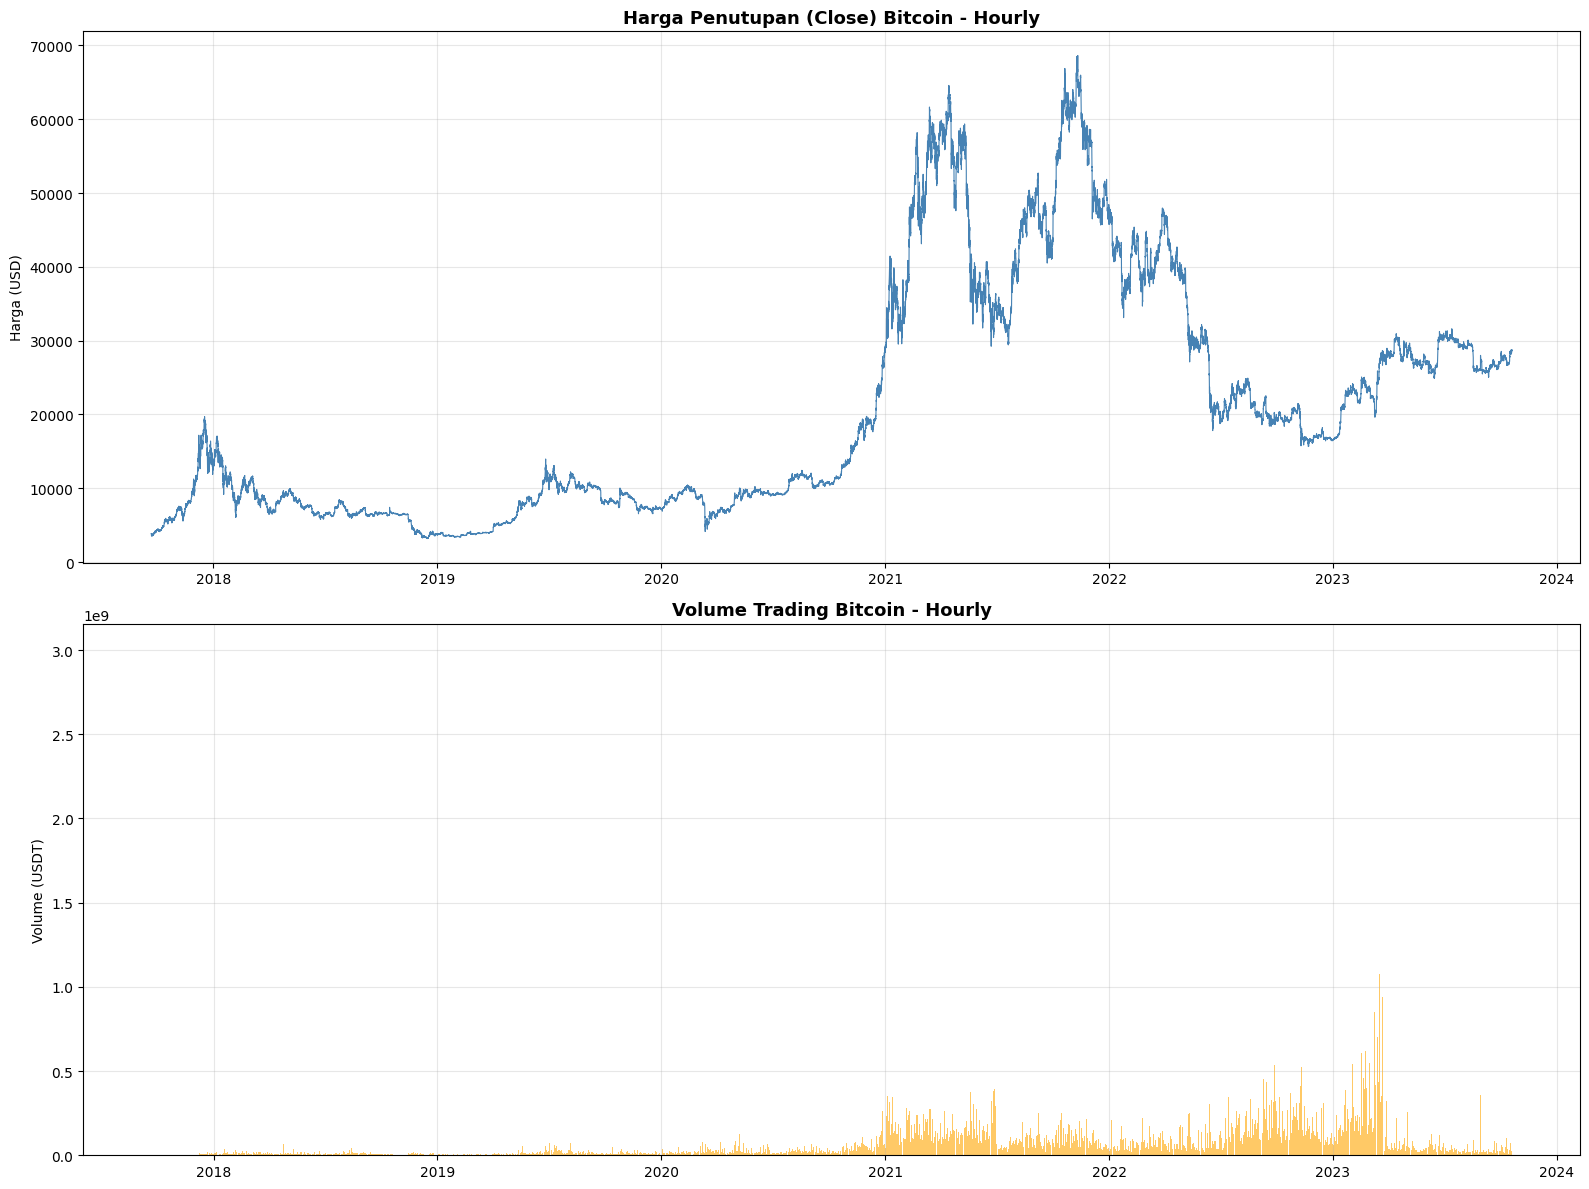

In [31]:
# Visualisasi Time Series Harga Close Bitcoin
fig, axes = plt.subplots(2, 1, figsize=(16, 12)) # Changed from 3 to 2 subplots

# Plot Close Price
axes[0].plot(df_raw.index, df_raw['Close'], color='steelblue', linewidth=0.8)
axes[0].set_title('Harga Penutupan (Close) Bitcoin - Hourly', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Harga (USD)')
axes[0].grid(alpha=0.3)

# Plot Volume
axes[1].bar(df_raw.index, df_raw['Volume USDT'], color='orange', alpha=0.6, width=0.04)
axes[1].set_title('Volume Trading Bitcoin - Hourly', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volume (USDT)') # Changed label to USDT
axes[1].grid(alpha=0.3)

# Removed the third subplot as 'high' and 'low' columns are not available in df_raw.

plt.tight_layout()
plt.show()

## Feature Engineering

In [32]:
# Feature Engineering - Rolling Statistics
df = df_raw.copy()

# Rolling Statistics (window 24 jam = 1 hari)
df['rolling_mean_24']  = df['Close'].rolling(window=24).mean()
df['rolling_std_24']   = df['Close'].rolling(window=24).std()
df['rolling_min_24']   = df['Close'].rolling(window=24).min()
df['rolling_max_24']   = df['Close'].rolling(window=24).max()

# Rolling Statistics (window 168 jam = 1 minggu)
df['rolling_mean_168'] = df['Close'].rolling(window=168).mean()

# Fitur tambahan: Price Change Percentage
df['price_change_pct'] = df['Close'].pct_change() * 100

# Volatility: rolling std / rolling mean
df['volatility_24']    = df['rolling_std_24'] / df['rolling_mean_24']

# Hapus NaN dari rolling
df.dropna(inplace=True)

print(f'Shape setelah feature engineering: {df.shape}')
print(f'Fitur yang tersedia: {df.columns.tolist()}')
df.tail()

Shape setelah feature engineering: (52983, 13)
Fitur yang tersedia: ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO', 'rolling_mean_24', 'rolling_std_24', 'rolling_min_24', 'rolling_max_24', 'rolling_mean_168', 'price_change_pct', 'volatility_24']


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,rolling_mean_24,rolling_std_24,rolling_min_24,rolling_max_24,rolling_mean_168,price_change_pct,volatility_24
Date,,,,,,,,,,,,,
2023-10-19 19:00:00,28750.75,2.984059e+07,53.630054,109.926882,129.065981,7.459700,28412.270000,165.004025,28210.0,28750.75,27633.282262,0.362237,0.005807
2023-10-19 20:00:00,28715.38,4.997623e+07,53.531282,111.721905,129.268969,7.118597,28431.843333,172.086206,28210.0,28750.75,27645.201786,-0.123023,0.006053
2023-10-19 21:00:00,28604.09,3.205666e+07,53.221944,113.055031,129.287930,6.210037,28446.500833,171.108243,28210.0,28750.75,27656.267798,-0.387562,0.006015
2023-10-19 22:00:00,28649.65,2.200420e+07,53.332673,114.513131,129.219782,6.515616,28462.331667,171.615664,28210.0,28750.75,27667.520000,0.159278,0.006030
2023-10-19 23:00:00,28713.71,1.758298e+07,53.487941,116.161806,129.096002,6.963753,28477.753750,177.025601,28210.0,28750.75,27679.178690,0.223598,0.006216


In [33]:
# Pilih Fitur Input (≥ 3 fitur sesuai rubrik)
# Menggunakan fitur: Close, Volume USDT, RSI, MACD_Hist, ATR, KAMAO, dan rolling features
FEATURES = ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO',
            'rolling_mean_24', 'rolling_std_24', 'rolling_min_24', 'rolling_max_24',
            'rolling_mean_168', 'price_change_pct', 'volatility_24']
TARGET   = 'Close'   # Target prediksi: harga Close
N_FEATURES = len(FEATURES)

data = df[FEATURES].copy()

print(f'Jumlah fitur input : {N_FEATURES} (≥ 3 ✓)')
print(f'Fitur input        : {FEATURES}')
print(f'Target prediksi    : {TARGET}')
print(f'Shape data         : {data.shape}')

Jumlah fitur input : 13 (≥ 3 ✓)
Fitur input        : ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO', 'rolling_mean_24', 'rolling_std_24', 'rolling_min_24', 'rolling_max_24', 'rolling_mean_168', 'price_change_pct', 'volatility_24']
Target prediksi    : Close
Shape data         : (52983, 13)


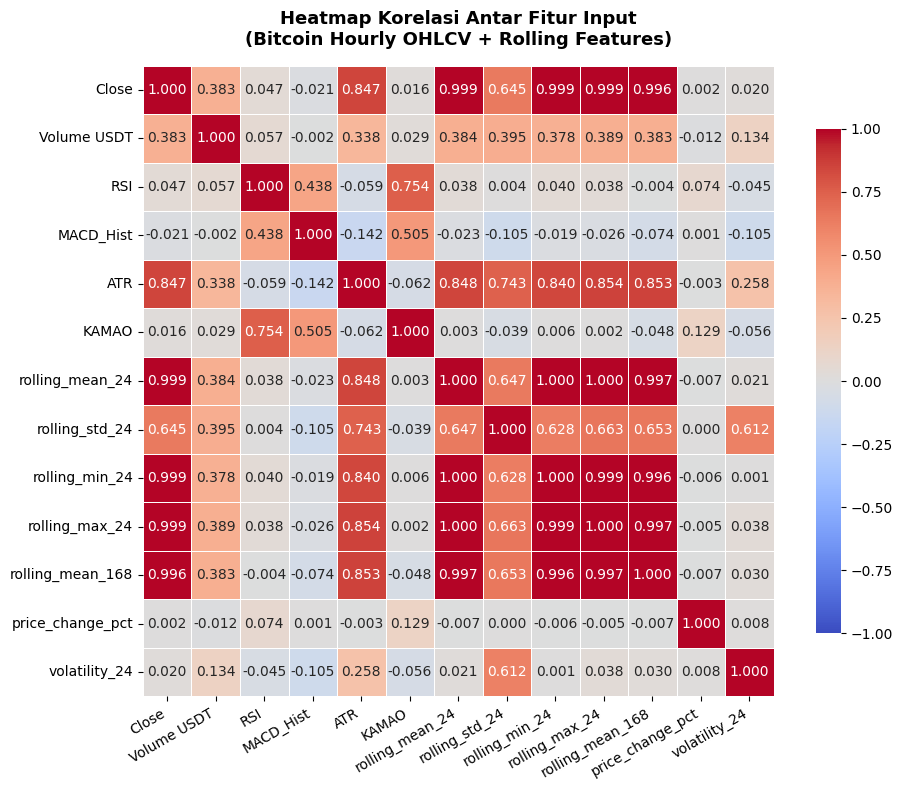


Nilai Korelasi terhadap fitur target (Close):
Close               1.000000
rolling_mean_24     0.999411
rolling_min_24      0.999217
rolling_max_24      0.999193
rolling_mean_168    0.995834
ATR                 0.847137
rolling_std_24      0.644800
Volume USDT         0.382745
RSI                 0.046602
volatility_24       0.019712
KAMAO               0.016283
price_change_pct    0.002393
MACD_Hist          -0.021025


In [34]:
# EDA - Heatmap Korelasi
plt.figure(figsize=(10, 8))
corr_matrix = data.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Antar Fitur Input\n(Bitcoin Hourly OHLCV + Rolling Features)',
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nNilai Korelasi terhadap fitur target (Close):')
print(corr_matrix['Close'].sort_values(ascending=False).to_string())

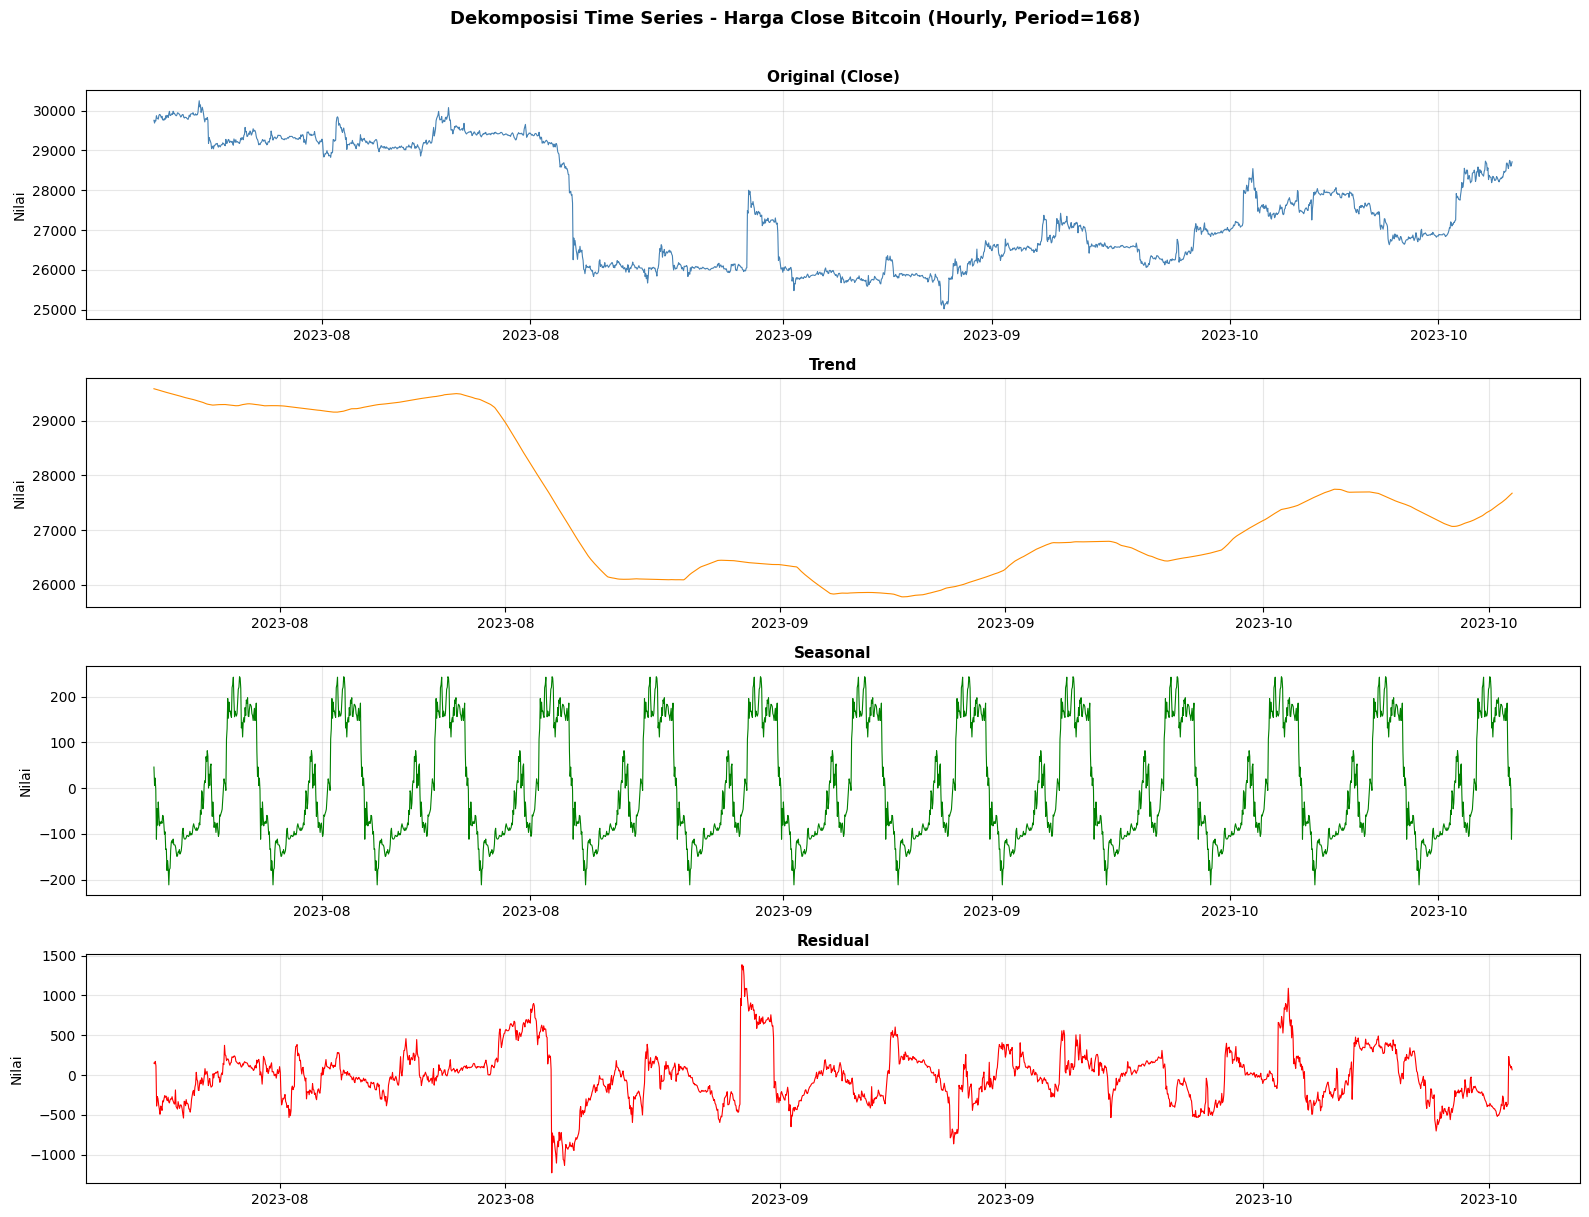

In [35]:
# Dekomposisi Data Target (Close Price)
# Gunakan subset data untuk efisiensi (3 bulan terakhir = ~2190 jam)
close_sample = data['Close'].iloc[-2190:]

# Dekomposisi additive dengan periode 168 (mingguan)
decomposition = seasonal_decompose(
    close_sample,
    model='additive',
    period=168   # 168 jam = 1 minggu
)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
components = {
    'Original (Close)' : close_sample,
    'Trend'            : decomposition.trend,
    'Seasonal'         : decomposition.seasonal,
    'Residual'         : decomposition.resid
}

colors = ['steelblue', 'darkorange', 'green', 'red']
for ax, (title, series), color in zip(axes, components.items(), colors):
    ax.plot(series.index, series.values, color=color, linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Nilai')
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.suptitle('Dekomposisi Time Series - Harga Close Bitcoin (Hourly, Period=168)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

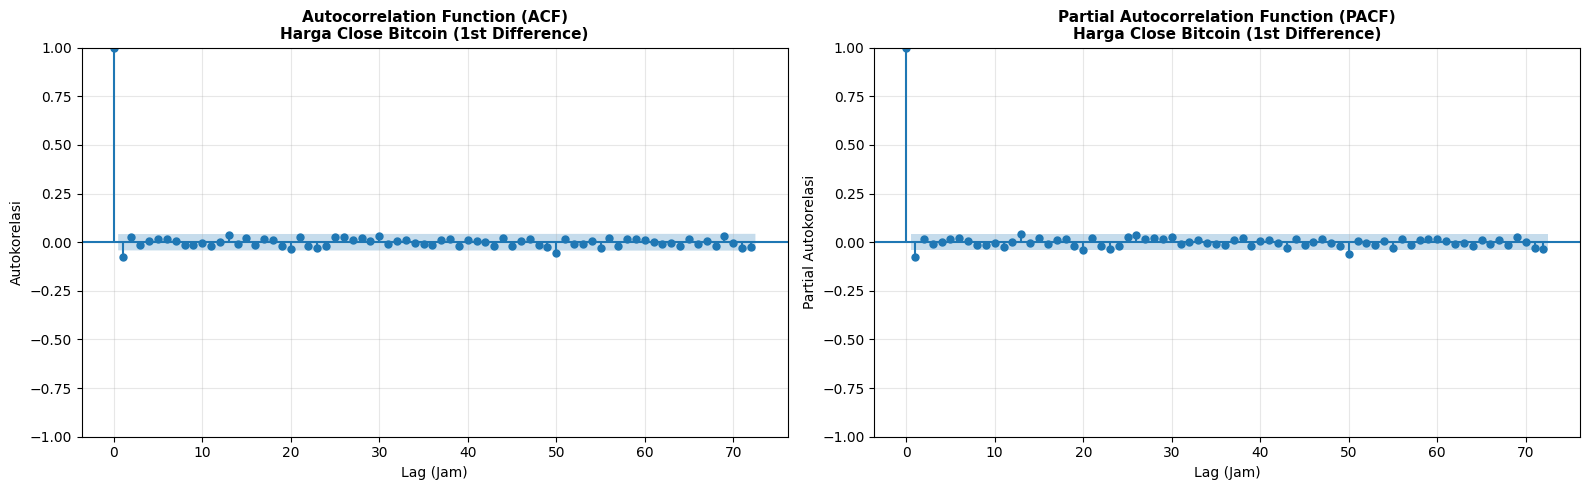

In [36]:
# ACF & PACF Plot untuk Menentukan Window Size
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gunakan difference agar stasioner
close_diff = close_sample.diff().dropna()

plot_acf(close_diff, lags=72, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF)\nHarga Close Bitcoin (1st Difference)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Lag (Jam)')
axes[0].set_ylabel('Autokorelasi')
axes[0].grid(alpha=0.3)

plot_pacf(close_diff, lags=72, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)\nHarga Close Bitcoin (1st Difference)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Lag (Jam)')
axes[1].set_ylabel('Partial Autokorelasi')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Split Data
# Hyperparameter utama
WINDOW_SIZE = 168   # Ditentukan dari hasil ACF/PACF (1 minggu)
HORIZON     = 24    # Multi-step: prediksi 24 jam ke depan
BATCH_SIZE  = 32

n          = len(data)
train_end  = int(n * 0.70)
val_end    = int(n * 0.85)

train_data = data.iloc[:train_end]
val_data   = data.iloc[train_end:val_end]
test_data  = data.iloc[val_end:]

print(f'Total data   : {n:,} jam')
print(f'Train        : {len(train_data):,} | {train_data.index[0].date()} — {train_data.index[-1].date()}')
print(f'Validation   : {len(val_data):,} | {val_data.index[0].date()} — {val_data.index[-1].date()}')
print(f'Test         : {len(test_data):,} | {test_data.index[0].date()} — {test_data.index[-1].date()}')

# ─── Normalisasi TERPISAH per kolom (sesuai Tips & Trick) ────────────────────
# Karena rentang nilai setiap fitur sangat berbeda (Close: ribuan USD,
# RSI: 0-100, Volume: jutaan, dll), setiap fitur dinormalisasi secara
# terpisah agar model tidak 'berpihak' ke fitur bernilai besar.
#
# Scaler di-fit HANYA pada data train → mencegah data leakage ke val/test.
# ─────────────────────────────────────────────────────────────────────────────
scalers = {}   # Dict: nama_kolom → scaler yang sudah di-fit

train_scaled_list = []
val_scaled_list   = []
test_scaled_list  = []

for col in FEATURES:
    sc = MinMaxScaler(feature_range=(0, 1))
    # Fit HANYA pada train
    train_col = sc.fit_transform(train_data[[col]])
    val_col   = sc.transform(val_data[[col]])       # transform only — no leakage
    test_col  = sc.transform(test_data[[col]])      # transform only — no leakage

    scalers[col] = sc
    train_scaled_list.append(train_col)
    val_scaled_list.append(val_col)
    test_scaled_list.append(test_col)

# Gabungkan semua kolom → shape (n_samples, N_FEATURES)
import numpy as np
train_scaled = np.hstack(train_scaled_list)
val_scaled   = np.hstack(val_scaled_list)
test_scaled  = np.hstack(test_scaled_list)

print(f'\nNormalisasi TERPISAH per kolom (no data leakage ✓)')
print(f'Scaler per fitur: {list(scalers.keys())}')
print(f'Shape train_scaled : {train_scaled.shape}')
print(f'Shape val_scaled   : {val_scaled.shape}')
print(f'Shape test_scaled  : {test_scaled.shape}')

# Contoh rentang nilai sebelum & sesudah normalisasi
print(f'\nContoh rentang nilai SEBELUM normalisasi (data train):')
for col in FEATURES:
    mn = train_data[col].min()
    mx = train_data[col].max()
    print(f'  {col:20s}: [{mn:.4f}, {mx:.4f}]')

print(f'\nRentang nilai SESUDAH normalisasi (semua fitur → [0, 1]):')
for i, col in enumerate(FEATURES):
    print(f'  {col:20s}: [{train_scaled[:, i].min():.4f}, {train_scaled[:, i].max():.4f}]')

Total data   : 52,983 jam
Train        : 37,088 | 2017-09-28 — 2021-12-26
Validation   : 7,947 | 2021-12-26 — 2022-11-22
Test         : 7,948 | 2022-11-22 — 2023-10-19

Normalisasi TERPISAH per kolom (no data leakage ✓)
Scaler per fitur: ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO', 'rolling_mean_24', 'rolling_std_24', 'rolling_min_24', 'rolling_max_24', 'rolling_mean_168', 'price_change_pct', 'volatility_24']
Shape train_scaled : (37088, 13)
Shape val_scaled   : (7947, 13)
Shape test_scaled  : (7948, 13)

Contoh rentang nilai SEBELUM normalisasi (data train):
  Close               : [3172.0500, 68633.6900]
  Volume USDT         : [0.0000, 1514464825.2185]
  RSI                 : [35.1788, 64.3365]
  MACD_Hist           : [-1885.6906, 1430.4058]
  ATR                 : [17.4363, 1004.5314]
  KAMAO               : [-31.7672, 30.8179]
  rolling_mean_24     : [3212.5458, 67566.1433]
  rolling_std_24      : [4.4749, 3493.4578]
  rolling_min_24      : [3172.0500, 66520.3700]


In [38]:
# Windowing Function - Multivariate Multi-Step
def make_multivariate_windows(window_tensor, horizon, n_features):
    # Encoder input: semua fitur dari masa lalu
    encoder_input = window_tensor[:-horizon]          # shape: (WINDOW_SIZE, N_FEATURES)

    # Decoder target: hanya fitur Close (kolom ke-0) di horizon ke depan
    decoder_target = window_tensor[-horizon:, 0:1]   # shape: (HORIZON, 1)

    # Teacher Forcing: start token + target[:-1]
    # Start token = nilai Close terakhir dari encoder input
    start_token  = encoder_input[-1:, 0:1]           # shape: (1, 1)
    decoder_input = tf.concat(
        [start_token, decoder_target[:-1]], axis=0   # shape: (HORIZON, 1)
    )

    return (encoder_input, decoder_input), decoder_target


def create_tf_dataset(scaled_array, window_size, horizon, batch_size,
                      n_features, shuffle=False):
    """
    Membuat tf.data.Dataset pipeline dari array NumPy yang sudah dinormalisasi.
    """
    total_window = window_size + horizon

    ds = tf.data.Dataset.from_tensor_slices(
        tf.cast(scaled_array, tf.float32)
    )
    ds = ds.window(total_window, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(total_window))
    ds = ds.map(
        lambda w: make_multivariate_windows(w, horizon, n_features),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# Buat dataset untuk train, val, test
train_ds = create_tf_dataset(train_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE, N_FEATURES, shuffle=True)
val_ds   = create_tf_dataset(val_scaled,   WINDOW_SIZE, HORIZON, BATCH_SIZE, N_FEATURES, shuffle=False)
test_ds  = create_tf_dataset(test_scaled,  WINDOW_SIZE, HORIZON, BATCH_SIZE, N_FEATURES, shuffle=False)

# Verifikasi shape
for (enc_in, dec_in), dec_tgt in train_ds.take(1):
    print(f'Verifikasi shape satu batch:')
    print(f'  encoder_input  : {enc_in.shape}  -> (batch, {WINDOW_SIZE}, {N_FEATURES})')
    print(f'  decoder_input  : {dec_in.shape}  -> (batch, {HORIZON}, 1)')
    print(f'  decoder_target : {dec_tgt.shape} -> (batch, {HORIZON}, 1)')

print('\ntf.data.Dataset pipeline siap (train/val/test) ✓')

Verifikasi shape satu batch:
  encoder_input  : (32, 168, 13)  -> (batch, 168, 13)
  decoder_input  : (32, 24, 1)  -> (batch, 24, 1)
  decoder_target : (32, 24, 1) -> (batch, 24, 1)

tf.data.Dataset pipeline siap (train/val/test) ✓


# Membangun Arsitektur Model Kustom

## Custom Layers

In [39]:
# Custom Dense Layer (dibuat ulang dari nol)
class CustomDenseLayer(layers.Layer):
    def __init__(self, units, activation=None, use_bias=True, **kwargs):
        super(CustomDenseLayer, self).__init__(**kwargs)
        self.units      = units
        self.activation = keras.activations.get(activation)
        self.use_bias   = use_bias

    def build(self, input_shape):
        # Inisialisasi bobot (kernel) dengan Glorot Uniform
        self.W = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        # Inisialisasi bias dengan zeros
        if self.use_bias:
            self.b = self.add_weight(
                name='bias',
                shape=(self.units,),
                initializer='zeros',
                trainable=True
            )
        super(CustomDenseLayer, self).build(input_shape)

    def call(self, inputs):
        # Operasi linear: x @ W + b
        output = tf.matmul(inputs, self.W)
        if self.use_bias:
            output = output + self.b
        # Terapkan fungsi aktivasi jika ada
        if self.activation is not None:
            output = self.activation(output)
        return output

    def compute_output_shape(self, input_shape):
        # Output shape adalah input shape dengan dimensi terakhir diganti oleh self.units
        return input_shape[:-1] + (self.units,)

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units, 'activation': keras.activations.serialize(self.activation), 'use_bias': self.use_bias})
        return config

print('CustomDenseLayer berhasil dibuat')
# Uji coba
_test_inp = tf.random.normal((2, 10))
_test_out = CustomDenseLayer(units=5, activation='relu')(_test_inp)
print(f'  Test: input shape {_test_inp.shape} -> output shape {_test_out.shape}')

CustomDenseLayer berhasil dibuat
  Test: input shape (2, 10) -> output shape (2, 5)


In [40]:
# Custom Multi-Head Attention Layer
class CustomMultiHeadAttention(layers.Layer):
     def __init__(self, num_heads, key_dim, **kwargs):
        super(CustomMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim   = key_dim
        self.depth     = key_dim // num_heads
        assert key_dim % num_heads == 0, 'key_dim harus habis dibagi num_heads'

        # Linear projection untuk Q, K, V, dan output
        self.wq = layers.Dense(key_dim, use_bias=False)
        self.wk = layers.Dense(key_dim, use_bias=False)
        self.wv = layers.Dense(key_dim, use_bias=False)
        self.wo = layers.Dense(key_dim)

    def split_heads(self, x, batch_size):
        """Split ke multiple heads: (batch, seq, key_dim) -> (batch, heads, seq, depth)"""
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, q, k, v):
        """Hitung attention weights: softmax(QK^T / sqrt(d_k)) * V"""
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled  = matmul_qk / tf.math.sqrt(dk)
        weights = tf.nn.softmax(scaled, axis=-1)
        output  = tf.matmul(weights, v)
        return output, weights

    def call(self, query, value, key=None):
        if key is None:
            key = value
        batch_size = tf.shape(query)[0]

        # Linear projections
        q = self.wq(query)
        k = self.wk(key)
        v = self.wv(value)

        # Split ke multiple heads
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        # Scaled dot-product attention per head
        attn_output, _ = self.scaled_dot_product_attention(q, k, v)

        # Concatenate heads: (batch, heads, seq, depth) -> (batch, seq, key_dim)
        attn_output = tf.transpose(attn_output, perm=[0, 2, 1, 3])
        concat_attn = tf.reshape(attn_output, (batch_size, -1, self.key_dim))

        # Linear projection output
        output = self.wo(concat_attn)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({'num_heads': self.num_heads, 'key_dim': self.key_dim})
        return config

print('CustomMultiHeadAttention berhasil dibuat')
_test_q = tf.random.normal((2, 24, 64))
_test_v = tf.random.normal((2, 168, 64))
_test_attn = CustomMultiHeadAttention(num_heads=4, key_dim=64)(_test_q, _test_v)
print(f'  Test: query {_test_q.shape}, value {_test_v.shape} -> output {_test_attn.shape}')

CustomMultiHeadAttention berhasil dibuat
  Test: query (2, 24, 64), value (2, 168, 64) -> output (2, 24, 64)


In [41]:
# Custom Dropout Layer
class CustomDropoutLayer(layers.Layer):
    def __init__(self, rate, **kwargs):
        super(CustomDropoutLayer, self).__init__(**kwargs)
        assert 0.0 <= rate < 1.0, 'rate harus berada di antara 0 dan 1'
        self.rate = rate

    def call(self, inputs, training=None):
        if training: # If training is True or a symbolic boolean tensor representing training mode
            # Buat mask Bernoulli
            keep_prob = 1.0 - self.rate
            mask = tf.cast(
                tf.random.uniform(tf.shape(inputs)) >= self.rate,
                dtype=inputs.dtype
            )
            # Scale output supaya ekspektasi tetap sama
            return (inputs * mask) / keep_prob
        return inputs # If training is False or None, return inputs directly

    def get_config(self):
        config = super().get_config()
        config.update({'rate': self.rate})
        return config

print('CustomDropoutLayer berhasil dibuat')

# Custom Layer Normalization Layer
class CustomLayerNorm(layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super(CustomLayerNorm, self).__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(
            name='gamma', shape=input_shape[-1:],
            initializer='ones', trainable=True
        )
        self.beta = self.add_weight(
            name='beta', shape=input_shape[-1:],
            initializer='zeros', trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        mean, variance = tf.nn.moments(inputs, axes=[-1], keepdims=True)
        normalized = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * normalized + self.beta

    def get_config(self):
        config = super().get_config()
        config.update({'epsilon': self.epsilon})
        return config

print('CustomLayerNorm berhasil dibuat')

CustomDropoutLayer berhasil dibuat
CustomLayerNorm berhasil dibuat


## Model Baseline LSTM dengan Custom Layers

In [42]:
# Model Baseline LSTM (Functional API)
# Dengan Custom Dense, Custom MHA, Custom Dropout, Custom LayerNorm
def build_baseline_lstm(window_size, horizon, n_features, lstm_units=128):
    inputs = layers.Input(shape=(window_size, n_features), name='lstm_input')

    # LSTM layers
    x = layers.LSTM(lstm_units, return_sequences=True, name='lstm_1')(inputs)
    x = CustomLayerNorm(name='layernorm_1')(x)
    x = CustomDropoutLayer(rate=0.2, name='dropout_1')(x)

    x = layers.LSTM(lstm_units // 2, return_sequences=True, name='lstm_2')(x)
    x = CustomLayerNorm(name='layernorm_2')(x)

    # Custom Multi-Head Attention (self-attention)
    attn_out = CustomMultiHeadAttention(
        num_heads=4, key_dim=lstm_units // 2, name='custom_mha'
    )(query=x, value=x)
    attn_out = CustomDropoutLayer(rate=0.1, name='dropout_2')(attn_out)

    # Residual connection
    x = layers.Add(name='residual_add')([x, attn_out])
    x = CustomLayerNorm(name='layernorm_3')(x)

    # Global average pooling
    x = CustomDenseLayer(units=64, activation='relu', name='custom_dense_1')(x[:, -1, :])
    x = CustomDropoutLayer(rate=0.1, name='dropout_3')(x)
    outputs = CustomDenseLayer(units=horizon, activation=None, name='custom_dense_output')(x)

    # Reshape ke (HORIZON, 1)
    outputs = layers.Reshape((horizon, 1), name='reshape_output')(outputs)

    model = Model(inputs=inputs, outputs=outputs, name='Baseline_LSTM_Custom')
    return model


baseline_lstm = build_baseline_lstm(
    window_size=WINDOW_SIZE,
    horizon=HORIZON,
    n_features=N_FEATURES,
    lstm_units=128
)
baseline_lstm.summary()

Model: "Baseline_LSTM_Custom"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lstm_input          │ (None, 168, 13)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 168, 128)  │     72,704 │ lstm_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layernorm_1         │ (None, 168, 128)  │        256 │ lstm_1[0][0]      │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1           │ (None, 168, 128)  │          0 │ layernorm_1[0][0] │
│ (CustomDropoutLaye… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 168, 64)   │     49,408 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layernorm_2         │ (None, 168, 64)   │        128 │ lstm_2[0][0]      │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_mha          │ (None, None, 64)  │     16,448 │ layernorm_2[0][0… │
│ (CustomMultiHeadAt… │                   │            │ layernorm_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2           │ (None, None, 64)  │          0 │ custom_mha[0][0]  │
│ (CustomDropoutLaye… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add (Add)  │ (None, None, 64)  │          0 │ layernorm_2[0][0… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layernorm_3         │ (None, None, 64)  │        128 │ residual_add[0][… │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 64)        │          0 │ layernorm_3[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_1      │ (None, 64)        │      4,160 │ get_item_1[0][0]  │
│ (CustomDenseLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3           │ (None, 64)        │          0 │ custom_dense_1[0… │
│ (CustomDropoutLaye… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_output │ (None, 24)        │      1,560 │ dropout_3[0][0]   │
│ (CustomDenseLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_output      │ (None, 24, 1)     │          0 │ custom_dense_out… │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 144,792 (565.59 KB)

 Trainable params: 144,792 (565.59 KB)

 Non-trainable params: 0 (0.00 B)

## Seq2Seq LSTM dengan Teacher Forcing

In [43]:
# Seq2Seq LSTM + Teacher Forcing (Functional API)
# Dengan Custom Dense, Custom MHA, Custom Dropout, Custom LayerNorm
def build_seq2seq_functional(window_size, horizon, n_features, lstm_units=128):
    # ---- ENCODER ----
    encoder_inputs = layers.Input(shape=(window_size, n_features), name='encoder_input')

    # Encoder LSTM 1
    enc_x = layers.LSTM(lstm_units, return_sequences=True, name='enc_lstm_1')(encoder_inputs)
    enc_x = CustomLayerNorm(name='enc_layernorm_1')(enc_x)
    enc_x = CustomDropoutLayer(rate=0.2, name='enc_dropout_1')(enc_x)

    # Encoder LSTM 2 - menghasilkan state
    enc_outputs, state_h, state_c = layers.LSTM(
        lstm_units, return_sequences=True, return_state=True, name='enc_lstm_2'
    )(enc_x)
    encoder_states = [state_h, state_c]

    # ---- DECODER ----
    decoder_inputs = layers.Input(shape=(horizon, 1), name='decoder_input')

    # Decoder LSTM (diinisialisasi dengan state dari encoder)
    dec_outputs, _, _ = layers.LSTM(
        lstm_units, return_sequences=True, return_state=True, name='dec_lstm'
    )(decoder_inputs, initial_state=encoder_states)

    dec_outputs = CustomDropoutLayer(rate=0.2, name='dec_dropout')(dec_outputs)

    # Custom Multi-Head Attention: decoder query ke encoder output (cross-attention)
    context = CustomMultiHeadAttention(
        num_heads=4, key_dim=lstm_units, name='cross_attention'
    )(query=dec_outputs, value=enc_outputs, key=enc_outputs)

    context = CustomLayerNorm(name='dec_layernorm_1')(context)
    context = CustomDropoutLayer(rate=0.1, name='dec_dropout_2')(context)

    # Gabungkan decoder output + context vector
    merged = layers.Concatenate(axis=-1, name='concat_dec_context')([dec_outputs, context])
    merged = CustomLayerNorm(name='dec_layernorm_2')(merged)

    # Output per timestep dengan CustomDenseLayer
    outputs = layers.TimeDistributed(
        CustomDenseLayer(units=64, activation='relu'), name='td_dense_1'
    )(merged)
    outputs = layers.TimeDistributed(
        CustomDenseLayer(units=1, activation=None), name='td_output'
    )(outputs)

    model = Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs=outputs,
        name='Seq2Seq_LSTM_Functional'
    )
    return model


seq2seq_functional = build_seq2seq_functional(
    window_size=WINDOW_SIZE,
    horizon=HORIZON,
    n_features=N_FEATURES,
    lstm_units=128
)
seq2seq_functional.summary()

Model: "Seq2Seq_LSTM_Functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 168, 13)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_lstm_1 (LSTM)   │ (None, 168, 128)  │     72,704 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_layernorm_1     │ (None, 168, 128)  │        256 │ enc_lstm_1[0][0]  │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_dropout_1       │ (None, 168, 128)  │          0 │ enc_layernorm_1[… │
│ (CustomDropoutLaye… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_lstm_2 (LSTM)   │ [(None, 168,      │    131,584 │ enc_dropout_1[0]… │
│                     │ 128), (None,      │            │                   │
│                     │ 128), (None,      │            │                   │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_lstm (LSTM)     │ [(None, 24, 128), │     66,560 │ decoder_input[0]… │
│                     │ (None, 128),      │            │ enc_lstm_2[0][1], │
│                     │ (None, 128)]      │            │ enc_lstm_2[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_dropout         │ (None, 24, 128)   │          0 │ dec_lstm[0][0]    │
│ (CustomDropoutLaye… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attention     │ (None, None, 128) │     65,664 │ enc_lstm_2[0][0], │
│ (CustomMultiHeadAt… │                   │            │ dec_dropout[0][0… │
│                     │                   │            │ enc_lstm_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_layernorm_1     │ (None, None, 128) │        256 │ cross_attention[… │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_dropout_2       │ (None, None, 128) │          0 │ dec_layernorm_1[… │
│ (CustomDropoutLaye… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dec_context  │ (None, 24, 256)   │          0 │ dec_dropout[0][0… │
│ (Concatenate)       │                   │            │ dec_dropout_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_layernorm_2     │ (None, 24, 256)   │        512 │ concat_dec_conte… │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_dense_1          │ (None, 24, 64)    │     16,448 │ dec_layernorm_2[… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_output           │ (None, 24, 1)     │         65 │ td_dense_1[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 354,049 (1.35 MB)

 Trainable params: 354,049 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

## Seq2Seq LSTM - Model Subclassing

In [44]:
# Seq2Seq LSTM dengan Model Subclassing
class Seq2SeqSubclassing(keras.Model):
    def __init__(self, window_size, horizon, n_features,
                 lstm_units=128, num_heads=4, dropout_rate=0.2, **kwargs):
        super(Seq2SeqSubclassing, self).__init__(**kwargs)
        self.window_size   = window_size
        self.horizon       = horizon
        self.n_features    = n_features
        self.lstm_units    = lstm_units

        # ---- Encoder components ----
        self.enc_lstm_1    = layers.LSTM(lstm_units, return_sequences=True, name='enc_lstm_1')
        self.enc_layernorm = CustomLayerNorm(name='enc_layernorm')
        self.enc_dropout   = CustomDropoutLayer(rate=dropout_rate, name='enc_dropout')
        self.enc_lstm_2    = layers.LSTM(lstm_units, return_sequences=True,
                                        return_state=True, name='enc_lstm_2')

        # ---- Decoder components ----
        self.dec_lstm      = layers.LSTM(lstm_units, return_sequences=True,
                                        return_state=True, name='dec_lstm')
        self.dec_dropout   = CustomDropoutLayer(rate=dropout_rate, name='dec_dropout')

        # ---- Custom Attention ----
        self.custom_mha    = CustomMultiHeadAttention(
            num_heads=num_heads, key_dim=lstm_units, name='custom_mha_subclass'
        )
        self.attn_layernorm = CustomLayerNorm(name='attn_layernorm')
        self.attn_dropout   = CustomDropoutLayer(rate=0.1, name='attn_dropout')

        # ---- Output layers ----
        self.concat_layer  = layers.Concatenate(axis=-1, name='concat')
        self.merge_norm    = CustomLayerNorm(name='merge_norm')
        self.out_dense_1   = CustomDenseLayer(units=64, activation='relu', name='out_dense_1')
        self.out_dense_2   = CustomDenseLayer(units=1,  activation=None,   name='out_dense_2')

    def encode(self, encoder_inputs, training=False):
        """Proses encoder: hasilkan encoder_outputs dan states."""
        x = self.enc_lstm_1(encoder_inputs, training=training)
        x = self.enc_layernorm(x)
        x = self.enc_dropout(x, training=training)
        enc_outputs, state_h, state_c = self.enc_lstm_2(x, training=training)
        return enc_outputs, [state_h, state_c]

    def decode(self, decoder_inputs, enc_outputs, enc_states, training=False):
        """Proses decoder dengan cross-attention ke encoder outputs."""
        dec_outputs, _, _ = self.dec_lstm(
            decoder_inputs, initial_state=enc_states, training=training
        )
        dec_outputs = self.dec_dropout(dec_outputs, training=training)

        # Cross-attention: decoder query ke encoder outputs
        context = self.custom_mha(query=dec_outputs, value=enc_outputs)
        context = self.attn_layernorm(context)
        context = self.attn_dropout(context, training=training)

        merged = self.concat_layer([dec_outputs, context])
        merged = self.merge_norm(merged)

        # Output per timestep
        out = self.out_dense_1(merged)
        out = self.out_dense_2(out)    # shape: (batch, horizon, 1)
        return out

    def call(self, inputs, training=False):
        encoder_inputs, decoder_inputs = inputs
        enc_outputs, enc_states = self.encode(encoder_inputs, training=training)
        predictions = self.decode(decoder_inputs, enc_outputs, enc_states, training=training)
        return predictions

    def get_config(self):
        return {
            'window_size' : self.window_size,
            'horizon'     : self.horizon,
            'n_features'  : self.n_features,
            'lstm_units'  : self.lstm_units,
        }


# Inisialisasi model subclassing
seq2seq_subclass = Seq2SeqSubclassing(
    window_size=WINDOW_SIZE,
    horizon=HORIZON,
    n_features=N_FEATURES,
    lstm_units=128,
    num_heads=4,
    name='Seq2Seq_LSTM_Subclassing'
)

# Build model dengan dummy input
dummy_enc = tf.zeros((1, WINDOW_SIZE, N_FEATURES))
dummy_dec = tf.zeros((1, HORIZON, 1))
_ = seq2seq_subclass((dummy_enc, dummy_dec))
seq2seq_subclass.summary()

print('\nSemua model berhasil dibuat:')
print(f'  1. Baseline LSTM          : {baseline_lstm.count_params():,} params')
print(f'  2. Seq2Seq Functional API : {seq2seq_functional.count_params():,} params')
print(f'  3. Seq2Seq Subclassing    : {seq2seq_subclass.count_params():,} params')

Model: "Seq2Seq_LSTM_Subclassing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_lstm_1 (LSTM)               │ (1, 168, 128)          │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_layernorm (CustomLayerNorm) │ ?                      │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dropout                     │ ?                      │             0 │
│ (CustomDropoutLayer)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm_2 (LSTM)               │ ((1, 168, 128), (1,    │       131,584 │
│                                 │ 128), (1, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm (LSTM)                 │ ((1, 24, 128), (1,     │        66,560 │
│                                 │ 128), (1, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dropout                     │ ?                      │             0 │
│ (CustomDropoutLayer)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_mha_subclass             │ ?                      │        65,664 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attn_layernorm                  │ ?                      │           256 │
│ (CustomLayerNorm)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attn_dropout                    │ ?                      │             0 │
│ (CustomDropoutLayer)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concat (Concatenate)            │ (1, 24, 256)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ merge_norm (CustomLayerNorm)    │ ?                      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out_dense_1 (CustomDenseLayer)  │ (1, 24, 64)            │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out_dense_2 (CustomDenseLayer)  │ (1, 24, 1)             │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,049 (1.35 MB)

 Trainable params: 354,049 (1.35 MB)

 Non-trainable params: 0 (0.00 B)


Semua model berhasil dibuat:
  1. Baseline LSTM          : 144,792 params
  2. Seq2Seq Functional API : 354,049 params
  3. Seq2Seq Subclassing    : 354,049 params


# Custom Training Loop

## Custom Loss Function

In [45]:
# Custom MAE Loss (dari nol)
class CustomMAELoss(keras.losses.Loss):
    def __init__(self, name='custom_mae_loss', **kwargs):
        super(CustomMAELoss, self).__init__(name=name, **kwargs)

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        abs_error = tf.abs(y_true - y_pred)
        return tf.reduce_mean(abs_error)

# Custom Weighted Horizon Loss # Error pada step yang lebih jauh diberi bobot lebih tinggi
class CustomWeightedHorizonLoss(keras.losses.Loss):
    def __init__(self, horizon=24, scale_factor=1.0,
                 name='custom_weighted_horizon_loss', **kwargs):
        super(CustomWeightedHorizonLoss, self).__init__(name=name, **kwargs)
        self.horizon      = horizon
        self.scale_factor = scale_factor

        # Bangun tensor bobot: shape (1, horizon, 1) untuk broadcast
        weights = tf.linspace(1.0, 1.0 + scale_factor, horizon)
        self.weights = tf.reshape(weights, (1, horizon, 1))

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        abs_error   = tf.abs(y_true - y_pred)          # (batch, horizon, 1)
        weighted    = abs_error * self.weights           # broadcast per step
        return tf.reduce_mean(weighted)

    def get_config(self):
        config = super().get_config()
        config.update({'horizon': self.horizon, 'scale_factor': self.scale_factor})
        return config


# Instansiasi loss
mae_loss            = CustomMAELoss()
weighted_horizon_loss = CustomWeightedHorizonLoss(horizon=HORIZON, scale_factor=1.0)

print('Custom Loss Functions siap')
# Uji coba loss
_y_true = tf.random.normal((4, 24, 1))
_y_pred = tf.random.normal((4, 24, 1))
print(f'  CustomMAELoss           : {mae_loss(_y_true, _y_pred).numpy():.6f}')
print(f'  CustomWeightedHorizonLoss: {weighted_horizon_loss(_y_true, _y_pred).numpy():.6f}')

Custom Loss Functions siap
  CustomMAELoss           : 1.043885
  CustomWeightedHorizonLoss: 1.548277


## Custom Callbacks

In [46]:
# Custom Early Stopping Callback
class CustomEarlyStopping:
    def __init__(self, patience=10, min_delta=1e-5, restore_best=True):
        self.patience      = patience
        self.min_delta     = min_delta
        self.restore_best  = restore_best
        self.best_loss     = np.inf
        self.wait          = 0
        self.stopped_epoch = 0
        self.best_weights  = None
        self.should_stop   = False

    def on_epoch_end(self, epoch, val_loss, model):
        if val_loss < (self.best_loss - self.min_delta):
            self.best_loss    = val_loss
            self.wait         = 0
            if self.restore_best:
                self.best_weights = model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                self.should_stop   = True
                if self.restore_best and self.best_weights is not None:
                    model.set_weights(self.best_weights)
                    print(f'\n[EarlyStopping] Epoch {epoch+1}: val_loss tidak membaik selama {self.patience} epoch.')
                    print(f'[EarlyStopping] Best val_loss={self.best_loss:.6f} | Bobot terbaik dipulihkan.')

print('CustomEarlyStopping siap')

# Custom LR Reducer Callback (Advanced)
class CustomLRReducer:
    def __init__(self, optimizer, factor=0.5, patience=5, min_lr=1e-7, verbose=True):
        self.optimizer = optimizer
        self.factor    = factor
        self.patience  = patience
        self.min_lr    = min_lr
        self.verbose   = verbose
        self.best_loss = np.inf
        self.wait      = 0

    def on_epoch_end(self, epoch, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.wait      = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                current_lr = float(self.optimizer.learning_rate)
                new_lr     = max(current_lr * self.factor, self.min_lr)
                self.optimizer.learning_rate.assign(new_lr)
                self.wait  = 0
                if self.verbose:
                    print(f'\n[LRReducer] Epoch {epoch+1}: LR dikurangi {current_lr:.2e} -> {new_lr:.2e}')

print('CustomLRReducer siap')

CustomEarlyStopping siap
CustomLRReducer siap


## Custom Training Loop

In [47]:
# Custom Training Loop Function (tf.GradientTape)
def custom_train_loop(model, train_ds, val_ds, optimizer, loss_fn,
                      epochs=50, model_name='model',
                      patience_es=10, patience_lr=5,
                      is_seq2seq=True):
    # Inisialisasi Callbacks
    early_stopper = CustomEarlyStopping(patience=patience_es, restore_best=True)
    lr_reducer    = CustomLRReducer(optimizer, factor=0.5, patience=patience_lr)

    # Metric trackers
    train_loss_metric = keras.metrics.Mean(name='train_loss')
    val_loss_metric   = keras.metrics.Mean(name='val_loss')

    history = {'loss': [], 'val_loss': []}

    print(f'\n{"="*60}')
    print(f'Training: {model_name}')
    print(f'{"="*60}')

    for epoch in range(epochs):
        train_loss_metric.reset_state()
        val_loss_metric.reset_state()

        # ---- Training Step ----
        for (enc_in, dec_in), dec_tgt in train_ds:
            with tf.GradientTape() as tape:
                if is_seq2seq:
                    y_pred = model((enc_in, dec_in), training=True)
                else:
                    y_pred = model(enc_in, training=True)
                loss = loss_fn(dec_tgt, y_pred)

            gradients = tape.gradient(loss, model.trainable_variables)
            # Gradient clipping untuk stabilitas
            gradients, _ = tf.clip_by_global_norm(gradients, clip_norm=1.0)
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))
            train_loss_metric.update_state(loss)

        # ---- Validation Step ----
        for (enc_in, dec_in), dec_tgt in val_ds:
            if is_seq2seq:
                y_pred = model((enc_in, dec_in), training=False)
            else:
                y_pred = model(enc_in, training=False)
            val_loss = loss_fn(dec_tgt, y_pred)
            val_loss_metric.update_state(val_loss)

        train_loss = float(train_loss_metric.result())
        val_loss   = float(val_loss_metric.result())

        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # Log setiap epoch
        current_lr = float(optimizer.learning_rate)
        print(f'Epoch {epoch+1:3d}/{epochs} | Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {current_lr:.2e}')

        # Callbacks
        lr_reducer.on_epoch_end(epoch, val_loss)
        early_stopper.on_epoch_end(epoch, val_loss, model)

        if early_stopper.should_stop:
            print(f'Training dihentikan lebih awal pada epoch {epoch+1}.')
            break

    print(f'\nTraining selesai. Best Val Loss: {early_stopper.best_loss:.6f}')
    return history


print('Custom Training Loop Function siap')

Custom Training Loop Function siap


## Training Model Baseline LSTM

In [48]:
# Training Baseline LSTM
optimizer_baseline = keras.optimizers.Adam(learning_rate=1e-3)

history_baseline = custom_train_loop(
    model       = baseline_lstm,
    train_ds    = train_ds,
    val_ds      = val_ds,
    optimizer   = optimizer_baseline,
    loss_fn     = mae_loss,            # Custom MAE Loss
    epochs      = 6,
    model_name  = 'Baseline LSTM',
    patience_es = 15,
    patience_lr = 7,
    is_seq2seq  = False                # Baseline LSTM: 1 input
)


Training: Baseline LSTM
Epoch   1/6 | Loss: 0.038220 | Val Loss: 0.027047 | LR: 1.00e-03
Epoch   2/6 | Loss: 0.029426 | Val Loss: 0.018083 | LR: 1.00e-03
Epoch   3/6 | Loss: 0.025712 | Val Loss: 0.027433 | LR: 1.00e-03
Epoch   4/6 | Loss: 0.025114 | Val Loss: 0.020299 | LR: 1.00e-03
Epoch   5/6 | Loss: 0.024557 | Val Loss: 0.025982 | LR: 1.00e-03
Epoch   6/6 | Loss: 0.024006 | Val Loss: 0.029693 | LR: 1.00e-03

Training selesai. Best Val Loss: 0.018083


## Training Seq2Seq

In [49]:
# Training Seq2Seq Functional API
# Menggunakan Custom Weighted Horizon Loss
optimizer_seq2seq = keras.optimizers.Adam(learning_rate=1e-3)

history_seq2seq = custom_train_loop(
    model       = seq2seq_functional,
    train_ds    = train_ds,
    val_ds      = val_ds,
    optimizer   = optimizer_seq2seq,
    loss_fn     = weighted_horizon_loss,   # Custom Weighted Horizon Loss
    epochs      = 6,
    model_name  = 'Seq2Seq Functional API',
    patience_es = 15,
    patience_lr = 7,
    is_seq2seq  = True
)


Training: Seq2Seq Functional API
Epoch   1/6 | Loss: 0.059750 | Val Loss: 0.107870 | LR: 1.00e-03
Epoch   2/6 | Loss: 0.025316 | Val Loss: 0.069348 | LR: 1.00e-03
Epoch   3/6 | Loss: 0.022057 | Val Loss: 0.069859 | LR: 1.00e-03
Epoch   4/6 | Loss: 0.018845 | Val Loss: 0.048450 | LR: 1.00e-03
Epoch   5/6 | Loss: 0.017041 | Val Loss: 0.063243 | LR: 1.00e-03
Epoch   6/6 | Loss: 0.015689 | Val Loss: 0.054530 | LR: 1.00e-03

Training selesai. Best Val Loss: 0.048450


## Training Seq2Seq Subclassing

In [50]:
# Training Seq2Seq Subclassing
# Menggunakan Custom Weighted Horizon Loss
optimizer_subclass = keras.optimizers.Adam(learning_rate=1e-3)

history_subclass = custom_train_loop(
    model       = seq2seq_subclass,
    train_ds    = train_ds,
    val_ds      = val_ds,
    optimizer   = optimizer_subclass,
    loss_fn     = weighted_horizon_loss,   # Custom Weighted Horizon Loss
    epochs      = 6,
    model_name  = 'Seq2Seq Subclassing',
    patience_es = 15,
    patience_lr = 7,
    is_seq2seq  = True
)


Training: Seq2Seq Subclassing
Epoch   1/6 | Loss: 0.066880 | Val Loss: 0.128411 | LR: 1.00e-03
Epoch   2/6 | Loss: 0.034590 | Val Loss: 0.068059 | LR: 1.00e-03
Epoch   3/6 | Loss: 0.023878 | Val Loss: 0.129123 | LR: 1.00e-03
Epoch   4/6 | Loss: 0.020638 | Val Loss: 0.081662 | LR: 1.00e-03
Epoch   5/6 | Loss: 0.017317 | Val Loss: 0.064528 | LR: 1.00e-03
Epoch   6/6 | Loss: 0.015081 | Val Loss: 0.030081 | LR: 1.00e-03

Training selesai. Best Val Loss: 0.030081


## Visualisasi Training History

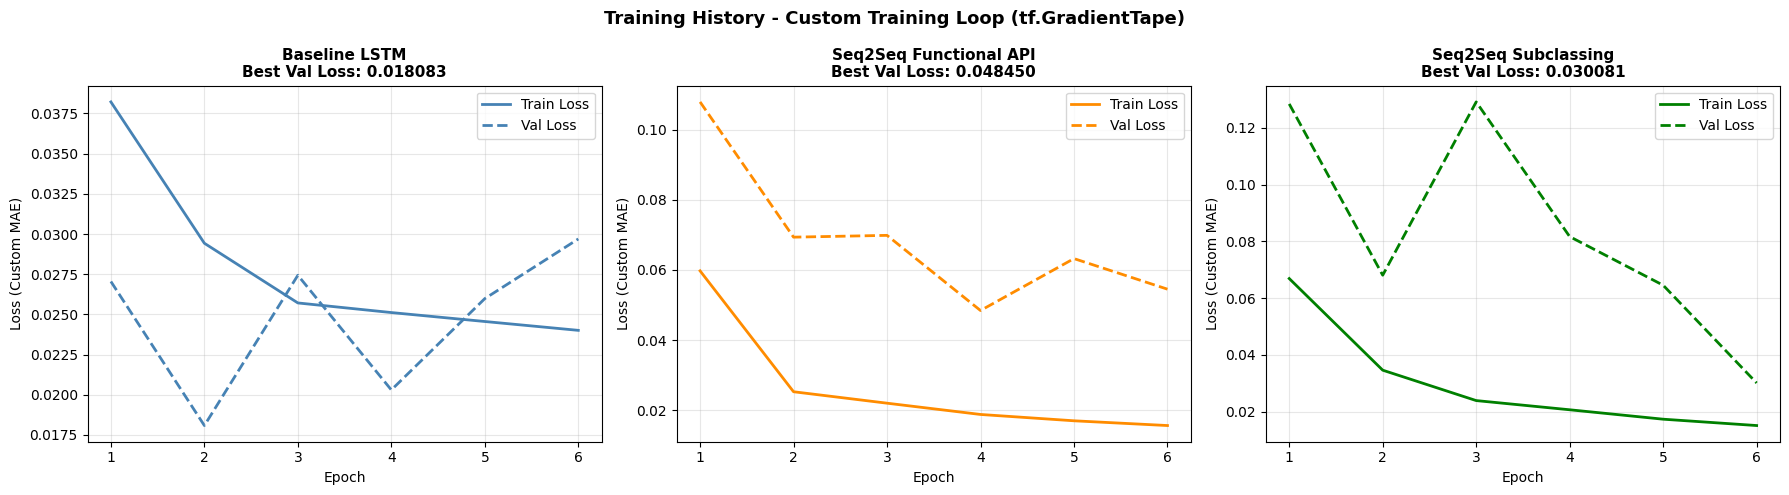

In [51]:
# Plot Training History semua model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

histories = [
    (history_baseline, 'Baseline LSTM',          'steelblue'),
    (history_seq2seq,  'Seq2Seq Functional API',  'darkorange'),
    (history_subclass, 'Seq2Seq Subclassing',     'green'),
]

for ax, (hist, name, color) in zip(axes, histories):
    epochs_ran = range(1, len(hist['loss']) + 1)
    ax.plot(epochs_ran, hist['loss'],     color=color,   linewidth=2, label='Train Loss')
    ax.plot(epochs_ran, hist['val_loss'], color=color,   linewidth=2, linestyle='--', label='Val Loss')
    ax.set_title(f'{name}\nBest Val Loss: {min(hist["val_loss"]):.6f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (Custom MAE)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training History - Custom Training Loop (tf.GradientTape)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Inference & Autoregressive Prediction

In [52]:
# Fungsi Inference - Autoregressive (untuk Seq2Seq)
def predict_autoregressive(model, encoder_input_seq, horizon, is_seq2seq=True):
    if not is_seq2seq:
        # Untuk baseline LSTM: prediksi langsung
        pred = model(encoder_input_seq, training=False)
        return pred.numpy().flatten()

    # Autoregressive: mulai dengan start token (nilai Close terakhir dari encoder)
    start_value  = encoder_input_seq[0, -1, 0]  # Close terakhir (sudah scaled)
    decoder_input = np.array([[[start_value]]])  # shape: (1, 1, 1)

    predictions = []

    # Loop autoregressive step-by-step
    # Bangun seluruh decoder input sekaligus (Teacher-Forcing mode dimatikan)
    # Untuk efficiency, kita lakukan full-sequence autoregressive
    current_decoder_seq = np.zeros((1, horizon, 1), dtype=np.float32)
    current_decoder_seq[0, 0, 0] = start_value

    for step in range(horizon):
        # Buat decoder input hingga step saat ini
        dec_in_partial = current_decoder_seq[:, :step+1, :]
        # Pad ke ukuran HORIZON
        dec_in_padded = np.zeros((1, horizon, 1), dtype=np.float32)
        dec_in_padded[0, :step+1, :] = dec_in_partial

        pred_full = model(
            (tf.constant(encoder_input_seq, dtype=tf.float32),
             tf.constant(dec_in_padded, dtype=tf.float32)),
            training=False
        )
        # Ambil prediksi untuk step saat ini
        current_pred = pred_full.numpy()[0, step, 0]
        predictions.append(current_pred)

        # Update decoder input untuk step berikutnya
        if step + 1 < horizon:
            current_decoder_seq[0, step + 1, 0] = current_pred

    return np.array(predictions)


print('Fungsi predict_autoregressive siap')

Fungsi predict_autoregressive siap


In [57]:
# Evaluasi pada Data Test
def evaluate_on_test(model, test_ds, loss_fn, model_name, is_seq2seq=True):
    test_loss_metric = keras.metrics.Mean()

    for (enc_in, dec_in), dec_tgt in test_ds:
        if is_seq2seq:
            y_pred = model((enc_in, dec_in), training=False)
        else:
            y_pred = model(enc_in, training=False)
        loss = loss_fn(dec_tgt, y_pred)
        test_loss_metric.update_state(loss)

    test_mae = float(test_loss_metric.result())
    print(f'{model_name} | MAE Test (sebelum inverse scale): {test_mae:.6f}')
    return test_mae


print('=== Evaluasi pada Data Test (Custom MAE Loss) ===')
mae_baseline  = evaluate_on_test(baseline_lstm,     test_ds, mae_loss, 'Baseline LSTM',          is_seq2seq=False)
mae_seq2seq   = evaluate_on_test(seq2seq_functional, test_ds, mae_loss, 'Seq2Seq Functional API',  is_seq2seq=True)
mae_subclass  = evaluate_on_test(seq2seq_subclass,  test_ds, mae_loss, 'Seq2Seq Subclassing',     is_seq2seq=True)

print(f'\n Target MAE < 0.015 (sebelum inverse scale):')
for name, mae in [('Baseline LSTM', mae_baseline), ('Seq2Seq Functional', mae_seq2seq), ('Seq2Seq Subclassing', mae_subclass)]:
    status = 'Lolos' if mae < 0.015 else 'Belum lolos'
    print(f'  {name}: {mae:.6f} {status}')

=== Evaluasi pada Data Test (Custom MAE Loss) ===
Baseline LSTM | MAE Test (sebelum inverse scale): 0.020976
Seq2Seq Functional API | MAE Test (sebelum inverse scale): 0.032947
Seq2Seq Subclassing | MAE Test (sebelum inverse scale): 0.013270

 Target MAE < 0.015 (sebelum inverse scale):
  Baseline LSTM: 0.020976 Belum lolos
  Seq2Seq Functional: 0.032947 Belum lolos
  Seq2Seq Subclassing: 0.013270 Lolos


## Visualisasi Hasil Prediksi

In [58]:
# Ambil Sampel dari Test Set untuk Visualisasi
# Ambil beberapa batch dari test_ds
all_enc_inputs, all_dec_targets = [], []

for (enc_in, dec_in), dec_tgt in test_ds.take(5):
    all_enc_inputs.append(enc_in.numpy())
    all_dec_targets.append(dec_tgt.numpy())

# Ambil sampel ke-0 dari batch ke-0
sample_enc_input  = all_enc_inputs[0][0:1]   # shape: (1, 168, 5)
sample_dec_target = all_dec_targets[0][0]     # shape: (24, 1) - scaled

# Prediksi dari ketiga model
pred_baseline  = predict_autoregressive(baseline_lstm,     sample_enc_input, HORIZON, is_seq2seq=False)
pred_seq2seq   = predict_autoregressive(seq2seq_functional, sample_enc_input, HORIZON, is_seq2seq=True)
pred_subclass  = predict_autoregressive(seq2seq_subclass,  sample_enc_input, HORIZON, is_seq2seq=True)
actual_scaled  = sample_dec_target.flatten()

print(f'Prediksi berhasil! Shape: {pred_seq2seq.shape}')

Prediksi berhasil! Shape: (24,)


In [59]:
# Inverse Transform ke Harga Asli (USD)
# Menggunakan scaler Close yang disimpan di dict 'scalers'
def inverse_close(scaled_vals):
    arr = np.array(scaled_vals).reshape(-1, 1)
    return scalers['Close'].inverse_transform(arr).flatten()


actual_usd    = inverse_close(actual_scaled)
pred_base_usd = inverse_close(pred_baseline)
pred_s2s_usd  = inverse_close(pred_seq2seq)
pred_sub_usd  = inverse_close(pred_subclass)

print('Inverse transform selesai (menggunakan scalers["Close"])')
print(f'Contoh harga aktual (USD): {actual_usd[:5].round(2)}')

Inverse transform selesai (menggunakan scalers["Close"])
Contoh harga aktual (USD): [16419.68 16426.56 16496.48 16465.95 16495.59]


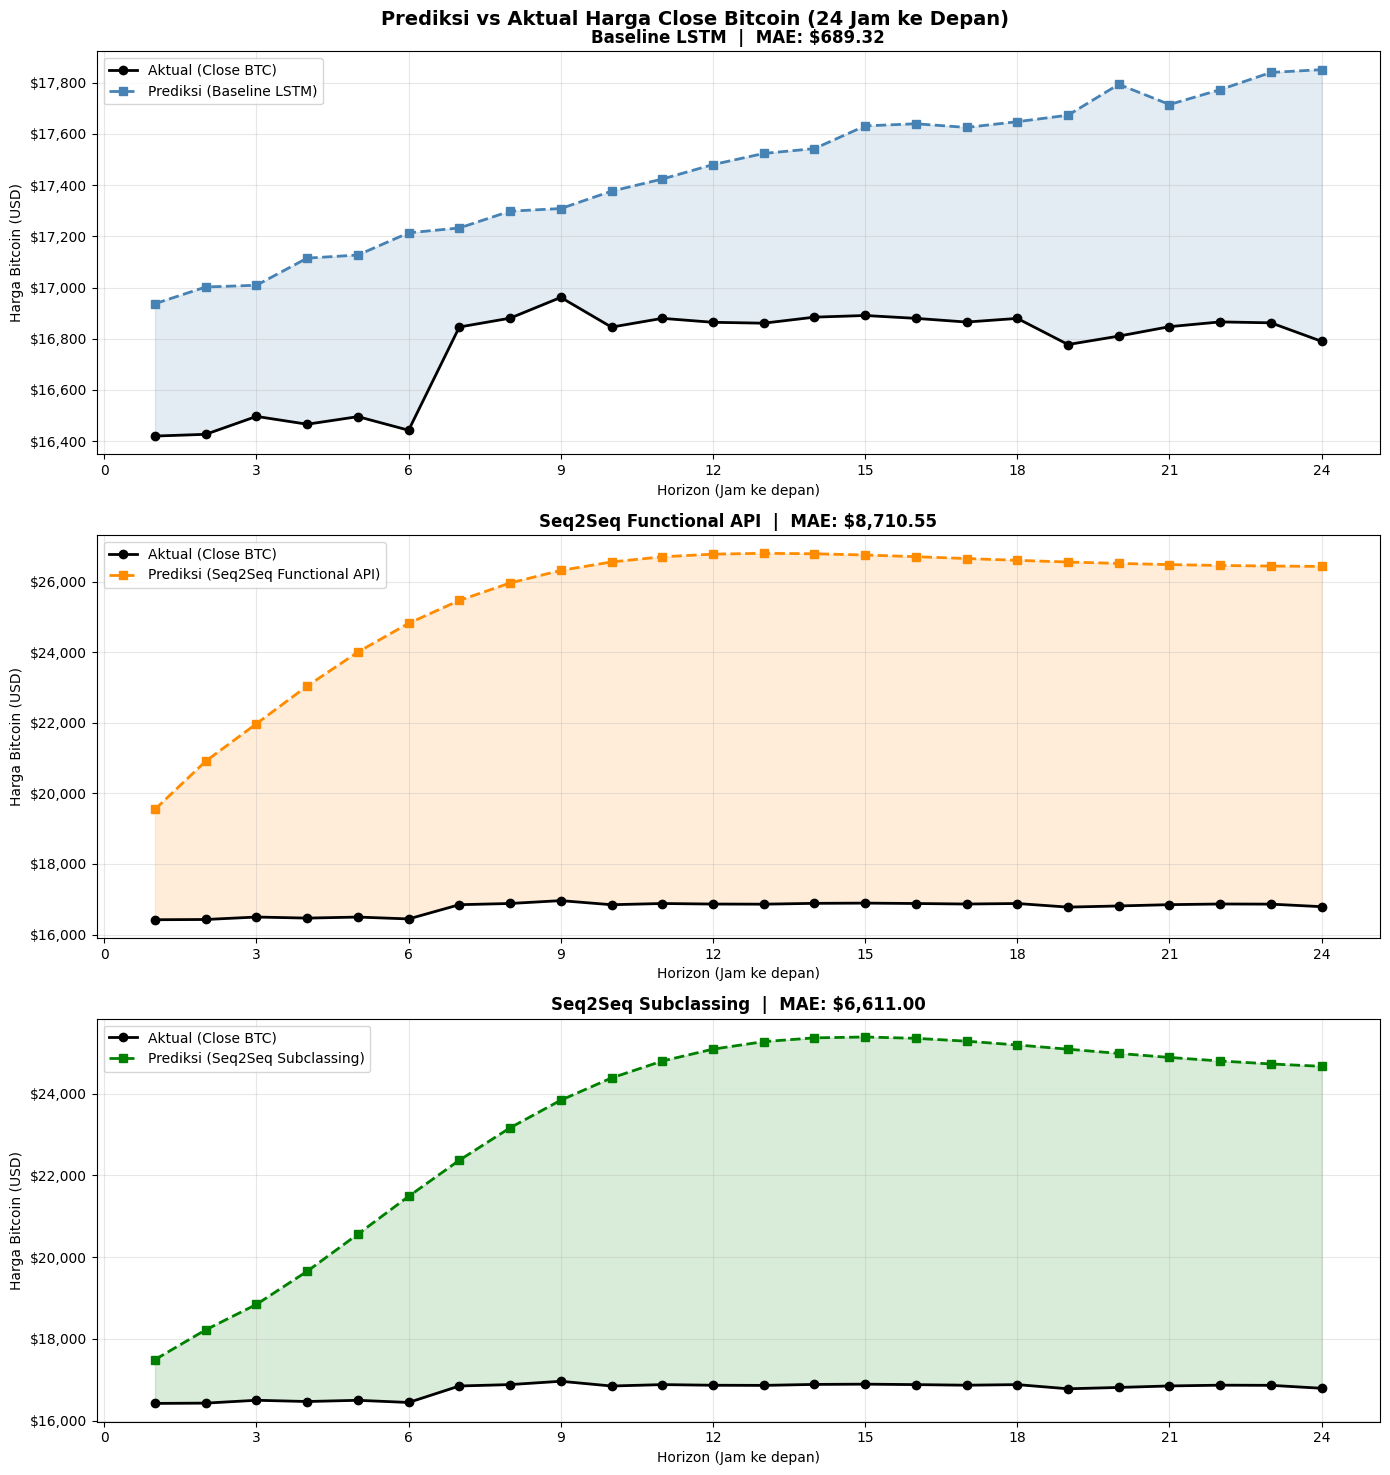

In [60]:
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

horizons = range(1, HORIZON + 1)
plot_configs = [
    (pred_base_usd,  'Baseline LSTM',         'steelblue',  axes[0]),
    (pred_s2s_usd,   'Seq2Seq Functional API', 'darkorange', axes[1]),
    (pred_sub_usd,  'Seq2Seq Subclassing',   'green',      axes[2]),
]

for pred, name, color, ax in plot_configs:
    mae_val = mean_absolute_error(actual_usd, pred)

    ax.plot(horizons, actual_usd, 'o-', color='black',
            linewidth=2, markersize=6, label='Aktual (Close BTC)', zorder=5)
    ax.plot(horizons, pred, 's--', color=color,
            linewidth=2, markersize=6, label=f'Prediksi ({name})', zorder=4)
    ax.fill_between(horizons, actual_usd, pred, alpha=0.15, color=color)

    ax.set_title(f'{name}  |  MAE: ${mae_val:,.2f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Horizon (Jam ke depan)')
    ax.set_ylabel('Harga Bitcoin (USD)')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Prediksi vs Aktual Harga Close Bitcoin (24 Jam ke Depan)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [62]:
# Tabel Perbandingan Aktual vs Prediksi
comparison_df = pd.DataFrame({
    'Horizon (Jam ke-)' : range(1, HORIZON + 1),
    'Aktual (USD)'      : actual_usd.round(2),
    'Pred Baseline LSTM': pred_base_usd.round(2),
    'Pred Seq2Seq Func' : pred_s2s_usd.round(2),
    'Pred Seq2Seq Sub'  : pred_sub_usd.round(2),
})

# Tambahkan kolom selisih
comparison_df['Selisih Baseline'] = (comparison_df['Pred Baseline LSTM'] - comparison_df['Aktual (USD)']).round(2)
comparison_df['Selisih Seq2Seq']  = (comparison_df['Pred Seq2Seq Func']  - comparison_df['Aktual (USD)']).round(2)
comparison_df['Selisih SubClass'] = (comparison_df['Pred Seq2Seq Sub']   - comparison_df['Aktual (USD)']).round(2)

# Format harga sebagai USD
def fmt_usd(x):
    return f'${x:,.2f}'

display_df = comparison_df.copy()
for col in ['Aktual (USD)', 'Pred Baseline LSTM', 'Pred Seq2Seq Func', 'Pred Seq2Seq Sub']:
    display_df[col] = display_df[col].apply(fmt_usd)

print('Tabel Perbandingan Data Aktual vs Hasil Prediksi (24 Langkah ke Depan)')
print('='*90)
print(display_df.to_string(index=False))
print('='*90)

# Ringkasan MAE
print('\nRingkasan MAE (dalam USD) pada data test:')
for name, pred in [('Baseline LSTM', pred_base_usd),
                   ('Seq2Seq Functional', pred_s2s_usd),
                   ('Seq2Seq Subclassing', pred_sub_usd)]:
    mae = mean_absolute_error(actual_usd, pred)
    print(f'  {name:25s}: MAE = ${mae:,.2f}')

Tabel Perbandingan Data Aktual vs Hasil Prediksi (24 Langkah ke Depan)
 Horizon (Jam ke-) Aktual (USD) Pred Baseline LSTM Pred Seq2Seq Func Pred Seq2Seq Sub  Selisih Baseline  Selisih Seq2Seq  Selisih SubClass
                 1   $16,419.68         $16,936.84        $19,548.40       $17,492.29        517.159973      3128.719971       1072.609985
                 2   $16,426.56         $17,002.02        $20,912.28       $18,220.41        575.460022      4485.720215       1793.849976
                 3   $16,496.48         $17,008.80        $21,974.37       $18,842.05        512.320007      5477.890137       2345.570068
                 4   $16,465.95         $17,114.72        $23,041.10       $19,653.09        648.770020      6575.149902       3187.139893
                 5   $16,495.59         $17,126.92        $24,004.86       $20,560.75        631.330017      7509.270020       4065.159912
                 6   $16,442.53         $17,213.57        $24,818.30       $21,486.31        77

## Simpan Model dalam Format Keras

In [63]:
#  Simpan Model dalam format .keras
custom_objects = {
    'CustomDenseLayer'         : CustomDenseLayer,
    'CustomMultiHeadAttention' : CustomMultiHeadAttention,
    'CustomDropoutLayer'       : CustomDropoutLayer,
    'CustomLayerNorm'          : CustomLayerNorm,
    'Seq2SeqSubclassing'       : Seq2SeqSubclassing,
    'CustomMAELoss'            : CustomMAELoss,
    'CustomWeightedHorizonLoss': CustomWeightedHorizonLoss,
}

# Simpan ketiga model
baseline_lstm.save('baseline_lstm.keras')
seq2seq_functional.save('seq2seq_functional.keras')
seq2seq_subclass.save('seq2seq_subclass.keras')

print('Model berhasil disimpan dalam format .keras:')
print('baseline_lstm.keras')
print('seq2seq_functional.keras')
print('seq2seq_subclass.keras')

Model berhasil disimpan dalam format .keras:
baseline_lstm.keras
seq2seq_functional.keras
seq2seq_subclass.keras
